<h1> Identify sites with unusual patterns compared to the network</h1>

<p>Let's start by reading in our sample black carbon data and its configuration file.</p>

In [1]:
import airinsights as air
import warnings
warnings.filterwarnings("ignore")

df, config = air.read_aqdata_file(input_file="sample_data/oakland_2017_100x100_blackcarbon.csv",
                                  config_file="../config/100x100_config.yaml")

Timestamp already in local timezone: America/Los_Angeles


The <code>anomalous_sites()</code> function identifies sites and hours of day with anomolously high levels of pollution based on a comparison between site-specific hourly means and network-wide hourly means across multiple timeframes: 30 days, 90 days, 1 year, and the entire period of record.

For each site, the function assigns a label based on the hours of day when elevated pollution is detected (Morning, Midday, Evening, Night, All Day, or None).

<small><code>help(air.anomalous_sites)</code> for more detail on the methodology.</small>

In [2]:
# --- Run function ---
sites = air.anomalous_sites(df, config)
sites.head()

,Site,hour,pollutant,site_mean,network_median,network_mad,z_score_mod,z_thresh,elevated,n_hours_elevated,times_elevated,timeframe,Latitude,Longitude
0,1,0,hourly_BC,0.526837,0.386268,0.050561,1.875203,1,True,24,All day,all_time,37.79364,-122.26343
1,1,1,hourly_BC,0.496531,0.360644,0.046797,1.958547,1,True,24,All day,all_time,37.79364,-122.26343
2,1,2,hourly_BC,0.471122,0.345368,0.050117,1.692436,1,True,24,All day,all_time,37.79364,-122.26343
3,1,3,hourly_BC,0.486735,0.336812,0.053884,1.876663,1,True,24,All day,all_time,37.79364,-122.26343
4,1,4,hourly_BC,0.598367,0.367363,0.051853,3.004823,1,True,24,All day,all_time,37.79364,-122.26343


<p>We can aggregate by site and timeframe to create a table that quickly shows which sites are experiencing unusual patterns, for how long, and at what times.<br>
Let's investigate the sites with the most unusual patterns using a 30 day timeframe.</p>

In [67]:
anomalous_sites_30d = (
    sites.loc[sites.timeframe == '30d']
    .groupby('Site')
    .agg({'n_hours_elevated': 'first','times_elevated': 'first', 'site_mean': 'mean'})
)

# Rename columns and drop sites with no unusual patterns
anomalous_sites_30d = (
    anomalous_sites_30d.loc[anomalous_sites_30d.times_elevated != 'None']
    .rename(
        columns = {
            'n_hours_elevated': '# of elevated hours', 
            'times_elevated': 'Times elevated', 
            'site_mean': 'Average BC (ug/m3)'
        }
    )
)

anomalous_sites_30d.sort_values("# of elevated hours", ascending=False).head(10)

,# of elevated hours,Times elevated,Average BC (ug/m3)
Site,,,
1,24,All day,1.046072
56,24,All day,0.927330
52,24,All day,1.343260
94,24,All day,1.221435
92,24,All day,1.033322
93,24,All day,0.852172
77,22,All day,0.765368
90,22,All day,1.037278
20,19,All day,0.708686


<h3>Visualizing the data</h3>

<p>With the table above, we can see there are several sites that are always elevated compared to the network, but are they following the same diurnal trend?<br>
We can plot the network median and site mean for each to find out.</p>

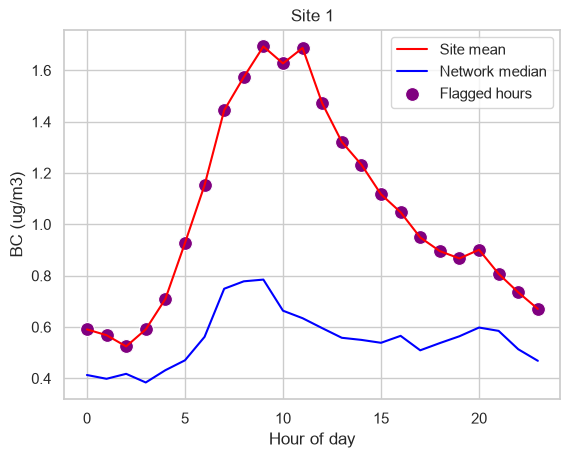

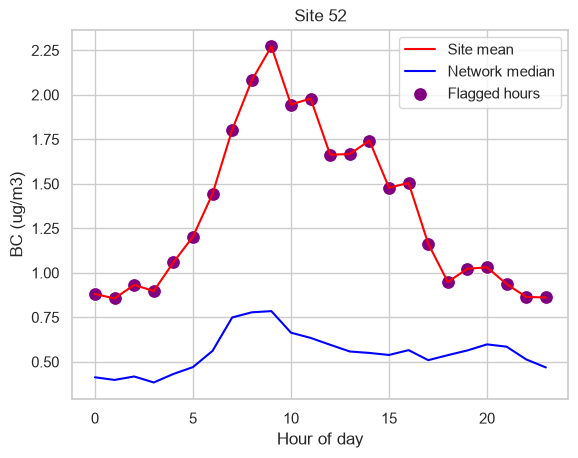

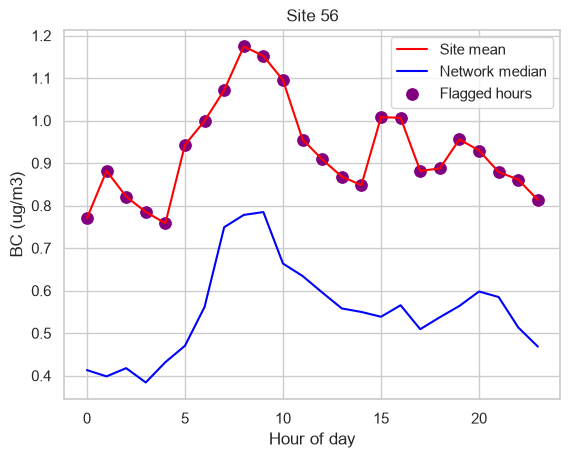

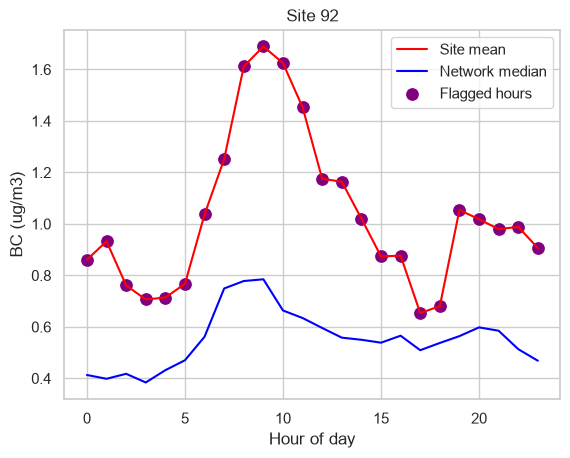

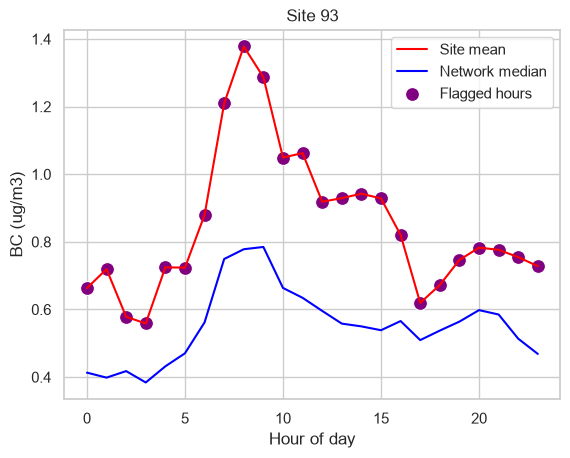

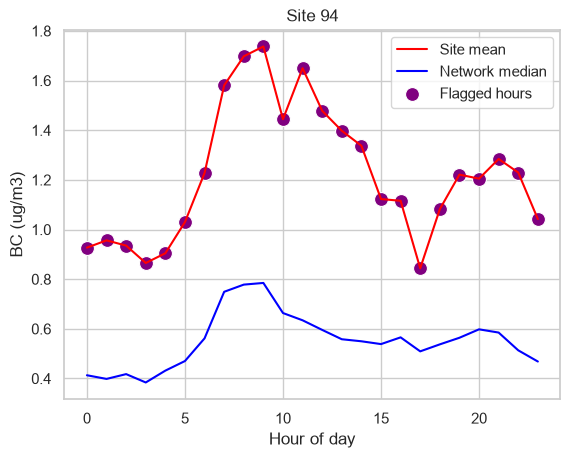

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

sites_30d = sites.loc[sites.timeframe == '30d']
sites_of_interest = sites_30d[sites_30d["n_hours_elevated"] == 24]["Site"].unique()

sns.set_theme(style="whitegrid")

for site in sites_of_interest:
    example_site_data = (
    (sites_30d[sites_30d.Site == site])[['hour', 'site_mean', 'network_median']]
    .rename(
        columns = {
            'hour': 'Hour of day',
            'site_mean': 'Site mean',
            'network_median': 'Network median'
        }
    )
    .set_index('Hour of day')
    )

    flagged_hours = (
        sites_30d[(sites_30d.Site == site) & sites_30d.elevated][['hour', 'site_mean', 'network_median']]
        .rename(
                columns = {
                    'hour': 'Hour of day',
                    'site_mean': 'Flagged hours',
                }
            )
    )
    ax = sns.lineplot(data = example_site_data, palette = ['red', 'blue'], dashes = False)
    sns.scatterplot(
        data=flagged_hours, 
        x='Hour of day', 
        y='Flagged hours', 
        s = 100,
        color = 'purple', 
        label = "Flagged hours"
    )

    ax.set_title(f'Site {site}')
    ax.set_ylabel('BC (ug/m3)')
    plt.show()

These methods and visualizations can easily communicate when sites are diverging from network patterns

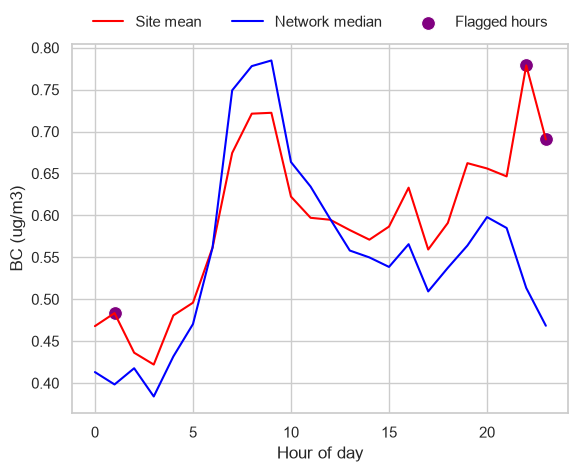

In [ ]:
sites_30d = sites.loc[sites.timeframe == '30d']
example_site = 5
example_site_data = (
    (sites_30d[sites_30d.Site == example_site])[['hour', 'site_mean', 'network_median']]
    .rename(
        columns = {
            'hour': 'Hour of day',
            'site_mean': 'Site mean',
            'network_median': 'Network median'
        }
    )
    .set_index('Hour of day')
)

flagged_hours = (
    sites_30d[(sites_30d.Site == example_site) & sites_30d.elevated][['hour', 'site_mean', 'network_median']]
    .rename(
            columns = {
                'hour': 'Hour of day',
                'site_mean': 'Flagged hours',
            }
        )
)

sns.set_theme(style="whitegrid")
ax = sns.lineplot(data = example_site_data, palette = ['red', 'blue'], dashes = False)
sns.scatterplot(
    data=flagged_hours, 
    x='Hour of day', 
    y='Flagged hours', 
    s = 100,
    color = 'purple', 
    label = "Flagged hours"
)
sns.move_legend(
    ax, "lower center",
    bbox_to_anchor=(.5, 1), ncol=3, title=None, frameon=False,
)
ax.set_ylabel('BC (ug/m3)')
plt.show()